In [1]:
import sys
import os
sys.path.append(os.path.abspath('../..'))

import torch
import matplotlib.pyplot as plt
import numpy as np
import torchvision.transforms as transforms

from src.generator import DynamicGenerator
from src.nn import DynamicCNN  
from src.utils import load_cifar10_data, initialize_defenders, initialize_attackers

In [2]:
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [3]:
def imshow_tensor(tensor, ax, is_noise=False):

    """Helper function to plot PyTorch image tensors (RGB or Grayscale)"""
    
    img = tensor.cpu().detach().numpy()
    img = np.transpose(img, (1, 2, 0)) # From (C, H, W) to (H, W, C)
    
    # If it's grayscale (MNIST), remove the channel dimension for matplotlib
    if img.shape[2] == 1:
        img = img.squeeze()
        cmap = 'gray'
    else:
        cmap = None

    img = (img + 1.0) / 2.0
    img = np.clip(img, 0, 1)
        
    ax.imshow(img, cmap=cmap)
    ax.axis('off')

In [4]:
def main_visualization():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # 1. Configurations for attackers and defenders
    attacker_configs = {strat['name']: strat for strat in initialize_attackers()}
    defender_configs = {strat['name']: strat for strat in initialize_defenders()}
    
    # 2. Load the data
    num_images = 5
    _, testloader = load_cifar10_data(batch_size=num_images)
    images, labels = next(iter(testloader))
    images = images[:num_images].to(device)
    labels = labels[:num_images].to(device)
    
    combats = [
        ('A1', 'D1'), ('A1', 'D10'), 
        ('A10', 'D1'), ('A10', 'D10')
    ]

    epsilon = 0.2
    models_dir = '../../output/models/models_10x10_eps_0.2'

    for att_name, def_name in combats:
        print(f"\n--- Preparing models for combat: {att_name} vs {def_name} ---")
        
        # Load models
        att_config = attacker_configs[att_name]
        generator = DynamicGenerator(
            in_channels=3, # Change to 1 if MNIST
            input_size=32, # Change to 28 if MNIST
            num_blocks=att_config['num_blocks'], 
            base_channels=att_config['base_channels']
        ).to(device)
        
        def_config = defender_configs[def_name]
        classifier = DynamicCNN(
            in_channels=3, # Change to 1 if MNIST
            input_size=32, # Change to 28 if MNIST
            num_blocks=def_config['num_blocks'],
            base_channels=def_config['base_channels']
        ).to(device)

        gen_path = os.path.join(models_dir, f"generator_{att_name}_vs_{def_name}.pth")
        class_path = os.path.join(models_dir, f"classifier_{def_name}_vs_{att_name}.pth")
            
        generator.load_state_dict(torch.load(gen_path, map_location=device))
        classifier.load_state_dict(torch.load(class_path, map_location=device))
        generator.eval()
        classifier.eval()

        # Generate attacks
        with torch.no_grad():
            x_adv, delta = generator(images, epsilon=epsilon)
            preds_orig = classifier(images).argmax(dim=1)
            preds_adv = classifier(x_adv).argmax(dim=1)

        # 3. DRAW ALL IMAGES FOR THE CURRENT COMBAT IN A SINGLE FIGURE
        fig, axes = plt.subplots(nrows=num_images, ncols=3, figsize=(12, 4 * num_images), squeeze=False)
        
        fig.suptitle(f"COMBAT: {att_name} vs {def_name} (Epsilon: {epsilon})", fontsize=18, fontweight='bold')

        for i in range(num_images):
            true_lbl = CIFAR10_CLASSES[labels[i].item()]
            p_orig_lbl = CIFAR10_CLASSES[preds_orig[i].item()]
            p_adv_lbl = CIFAR10_CLASSES[preds_adv[i].item()]
            
            color_orig = 'green' if labels[i] == preds_orig[i] else 'red'
            color_adv = 'green' if labels[i] == preds_adv[i] else 'red'

            # 1. Original Image (Row i, Column 0)
            imshow_tensor(images[i], axes[i, 0])
            axes[i, 0].set_title(f"ORIGINAL\nTrue: {true_lbl}\nPred: {p_orig_lbl}", color=color_orig, fontweight='bold')

            # 2. Noise (Row i, Column 1)
            imshow_tensor(delta[i], axes[i, 1], is_noise=True)
            axes[i, 1].set_title(f"NOISE ({att_name})\nEpsilon: {epsilon}", fontweight='bold')

            # 3. Attacked Image (Row i, Column 2)
            imshow_tensor(x_adv[i], axes[i, 2])
            axes[i, 2].set_title(f"ADVERSARIAL vs {def_name}\nPred: {p_adv_lbl}", color=color_adv, fontweight='bold')

        plt.tight_layout()
        plt.subplots_adjust(top=0.92 if num_images > 2 else 0.85) 
        
        # To save the full combat figure automatically
        # folder = "../../output/figures"
        # os.makedirs(folder, exist_ok=True)
        # plt.savefig(f"{folder}/combat_{att_name}_vs_{def_name}.png")
        
        plt.show()

Using device: cuda
Files already downloaded and verified


c:\Users\win11\Documents\Guillem\TFG\Adversarial-Attacks-on-Neural-Networks-A-Game-Theory-Approach\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified

--- Preparing models for combat: A1 vs D1 ---


C:\Users\win11\AppData\Local\Temp\ipykernel_3692\2011162584.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  generator.load_state_dict(torch.load(gen_path, map_location=

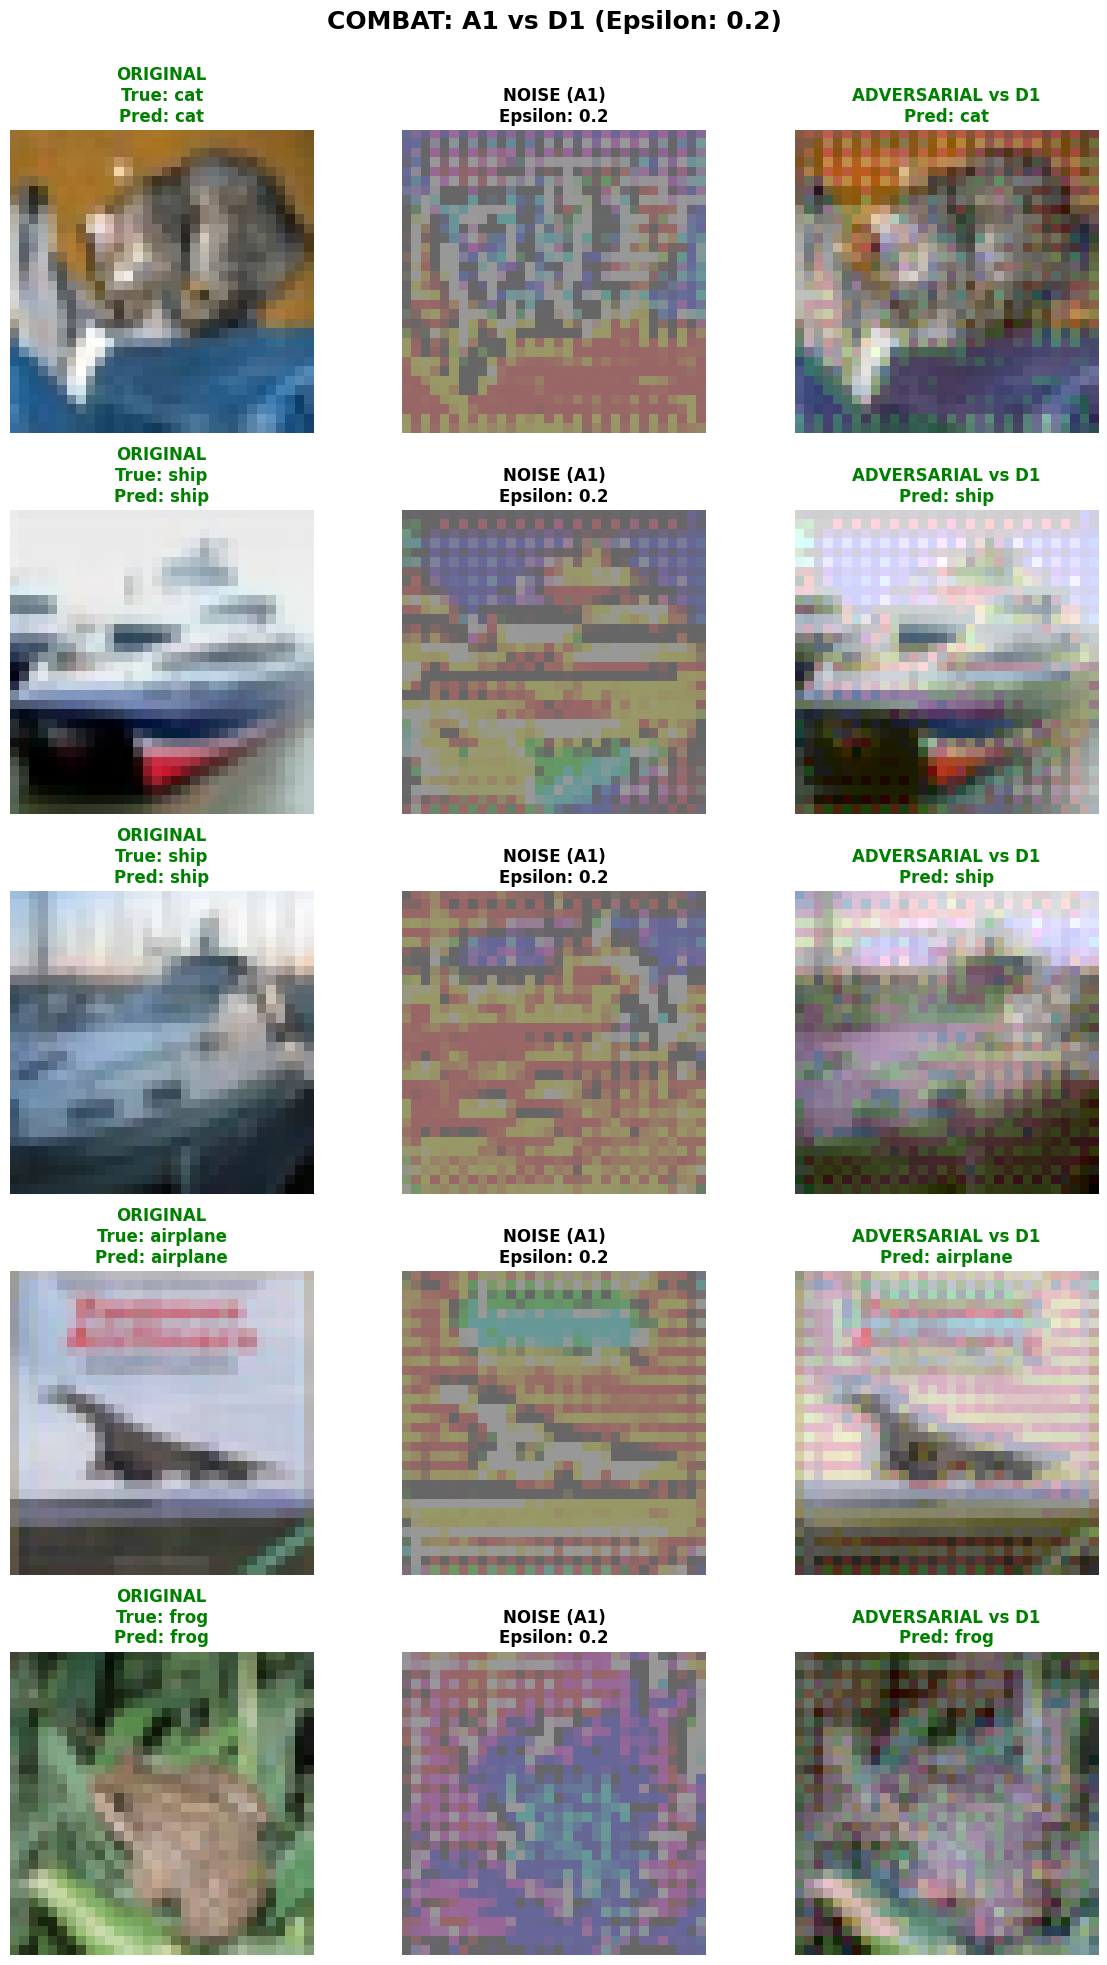


--- Preparing models for combat: A1 vs D10 ---


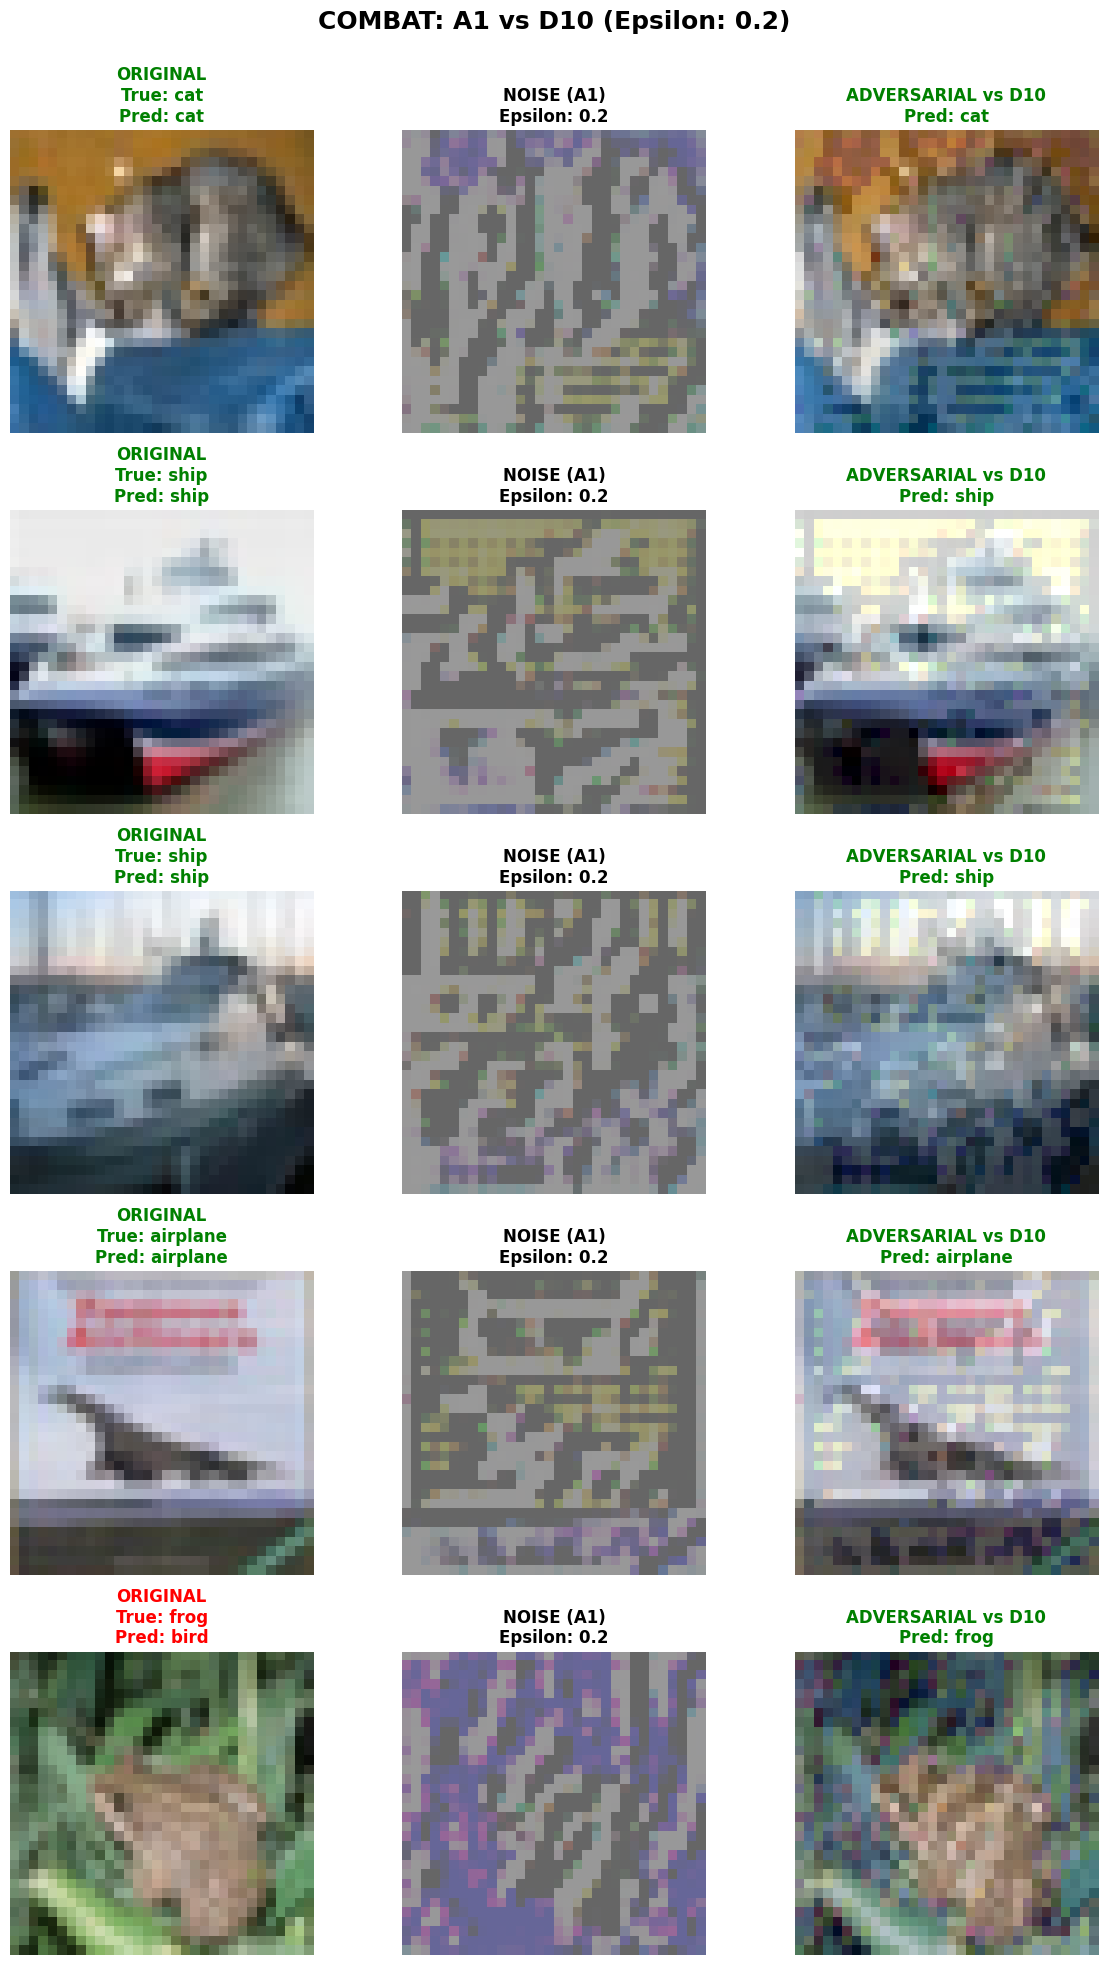


--- Preparing models for combat: A10 vs D1 ---


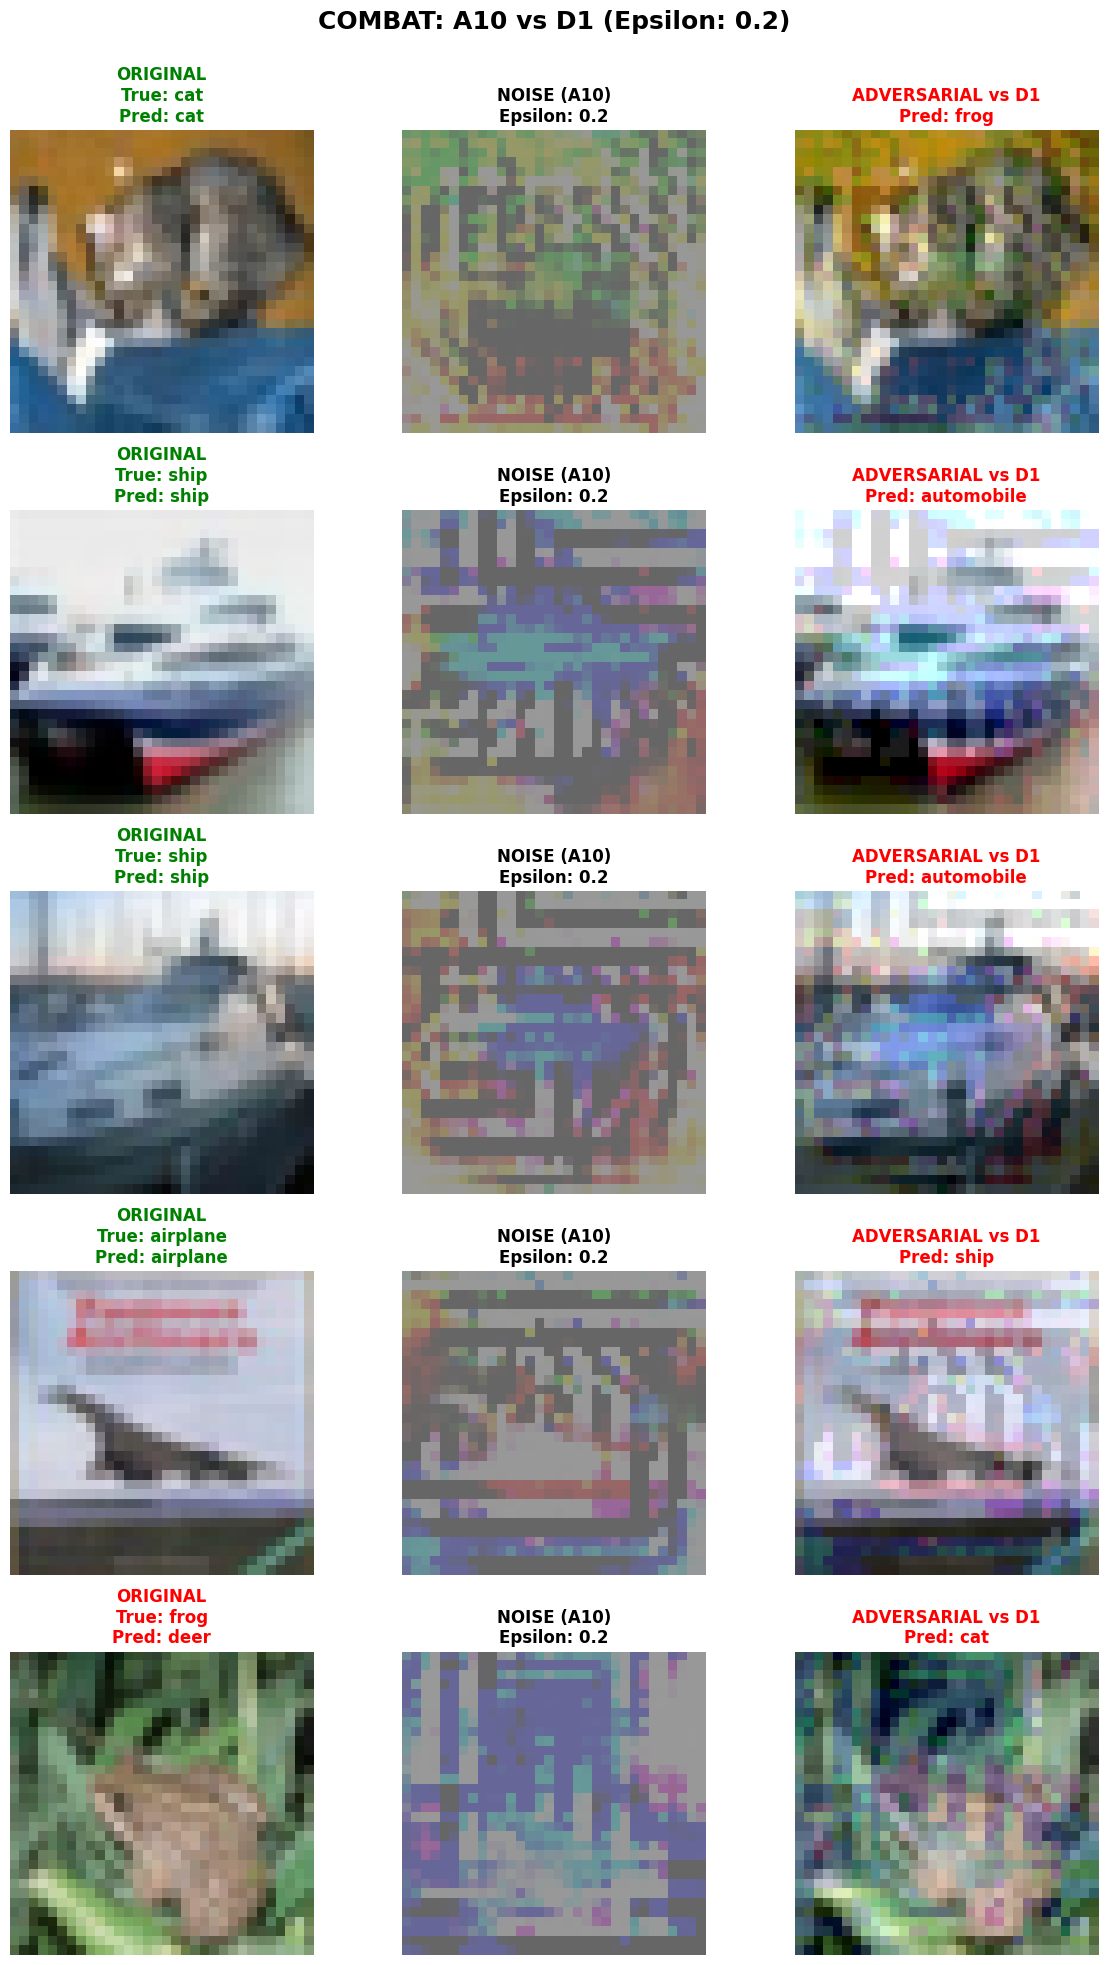


--- Preparing models for combat: A10 vs D10 ---


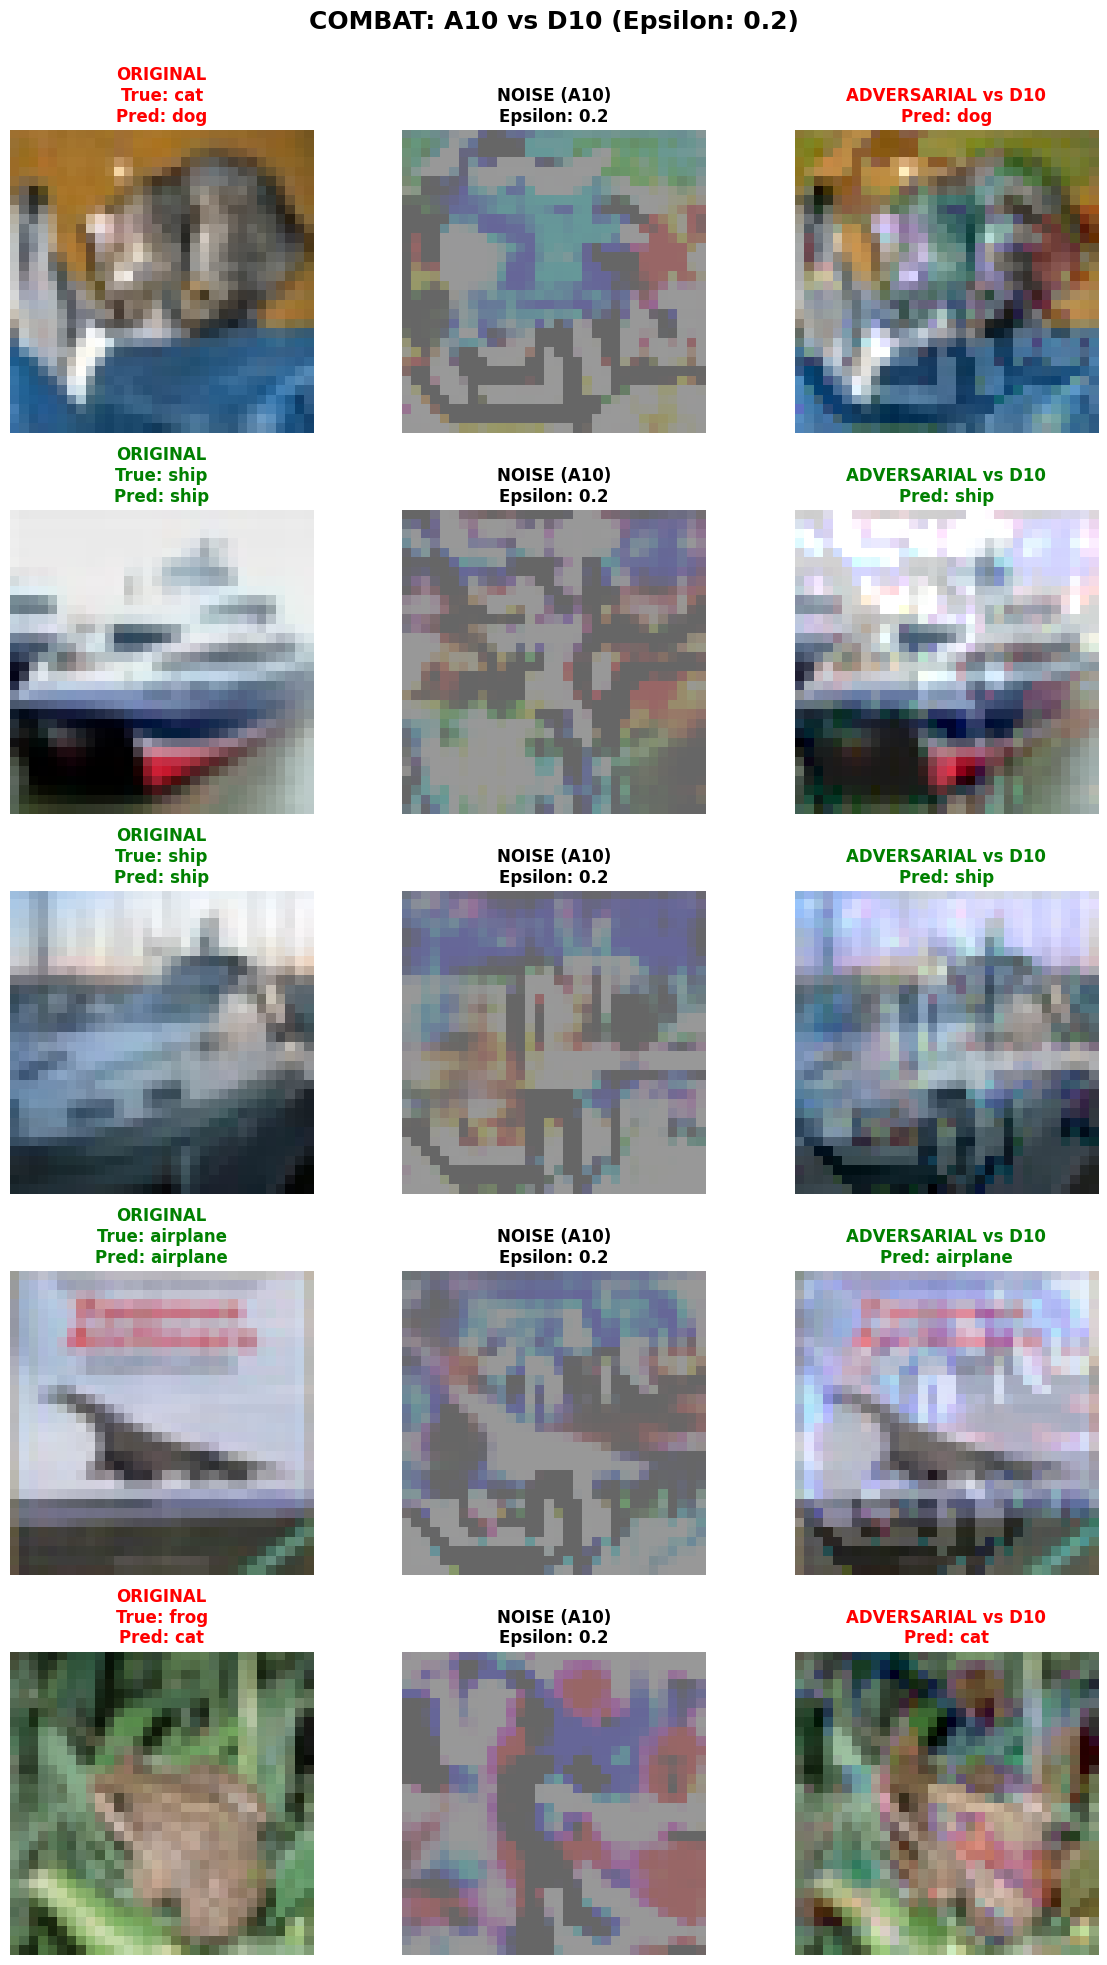

In [5]:
main_visualization()